In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Markdown, display

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from data.share_data import load_share_data
from scripts.misocp import plot_misocp_outputs, run_global_misocp
from utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/20260504_234339_01e73bd1")
cfg, run_dir = load_experiment_context(run_dir)
share_data = load_share_data(run_dir / "share_data", cfg)
display(Markdown("# MADRL_ESS MISOCP"))
display(pd.DataFrame([{"run_dir": str(run_dir), "eval_start": cfg.data.eval_start_date, "eval_end": cfg.data.eval_end_date, "eval_episodes": int(share_data.eval["price"].shape[0])}]))


# MADRL_ESS MISOCP

,run_dir,eval_start,eval_end,eval_episodes
0,artifacts\runs\20260504_234339_01e73bd1,2020-04-01,2020-04-15,15


In [3]:
record = run_global_misocp(cfg, run_dir, share_data)
display(Markdown("## Metrics"))
display(record["metrics_df"])
display(Markdown("## Agent Summary"))
display(record["rollout"].summary)
pprint({"record_dir": str(record["record_dir"])})


Global MISOCP/perfect:   0%|          | 0/15 [00:00<?, ?episode/s]

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2685996


Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


...

{

'record_dir'

: 

'artifacts\\runs\\20260504_234339_01e73bd1\\results\\perfect\\MISOCP\\record'

}

C:\Users\10856\Desktop\GithubProject\MADRL_ESS\utils\records.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


1. 电力电量平衡

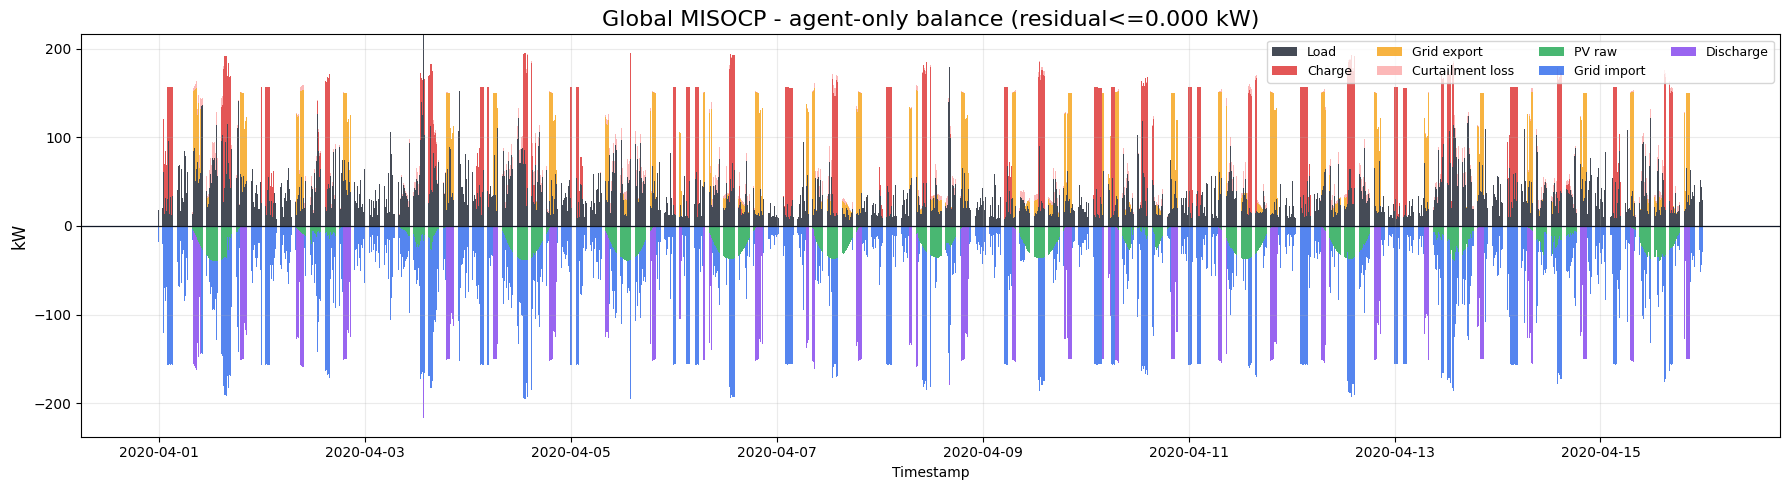

2. 电价

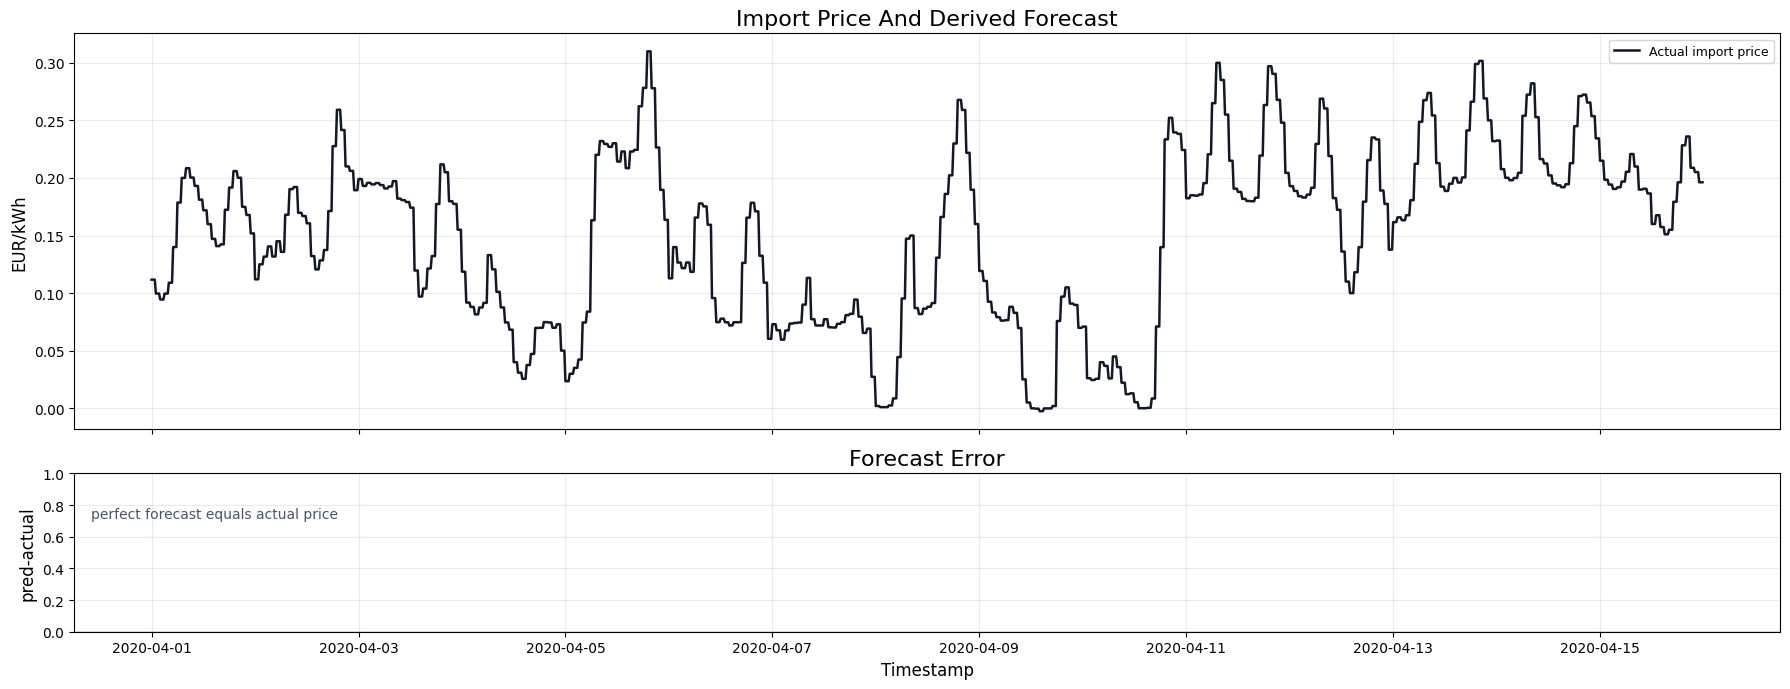

3. 总体储能充放功率与 SoC

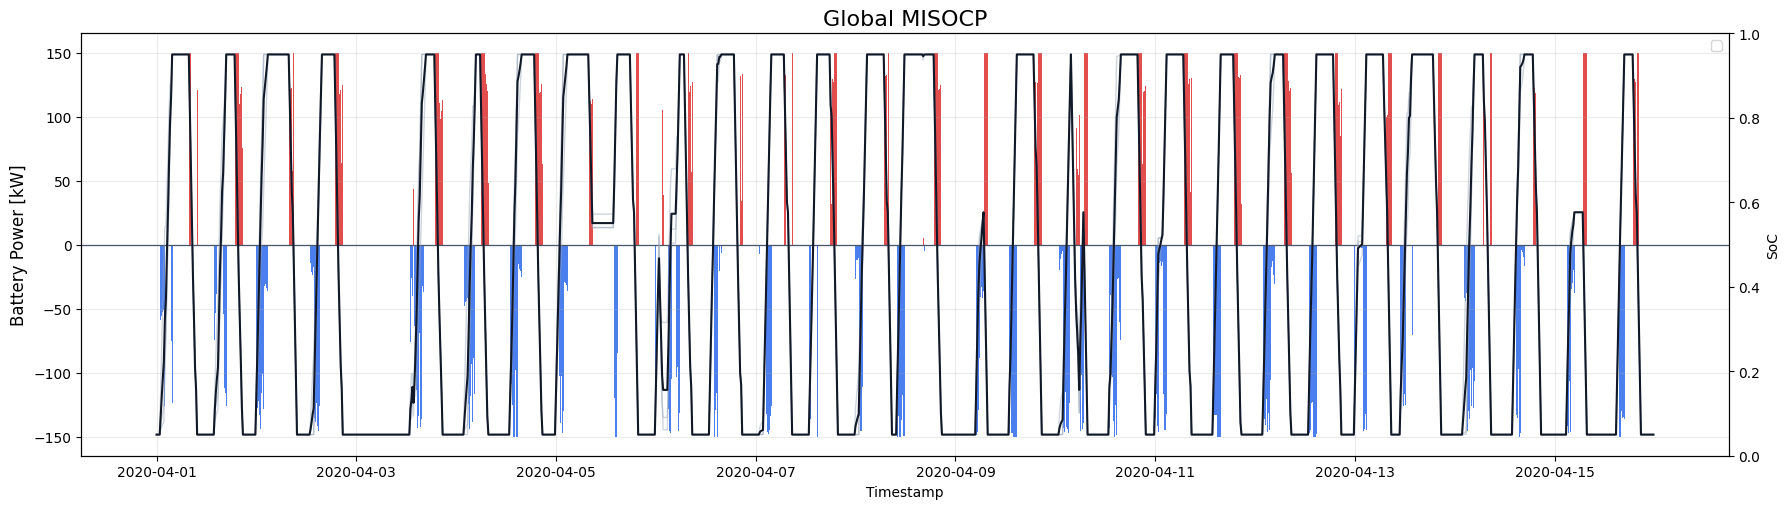

4. 电压

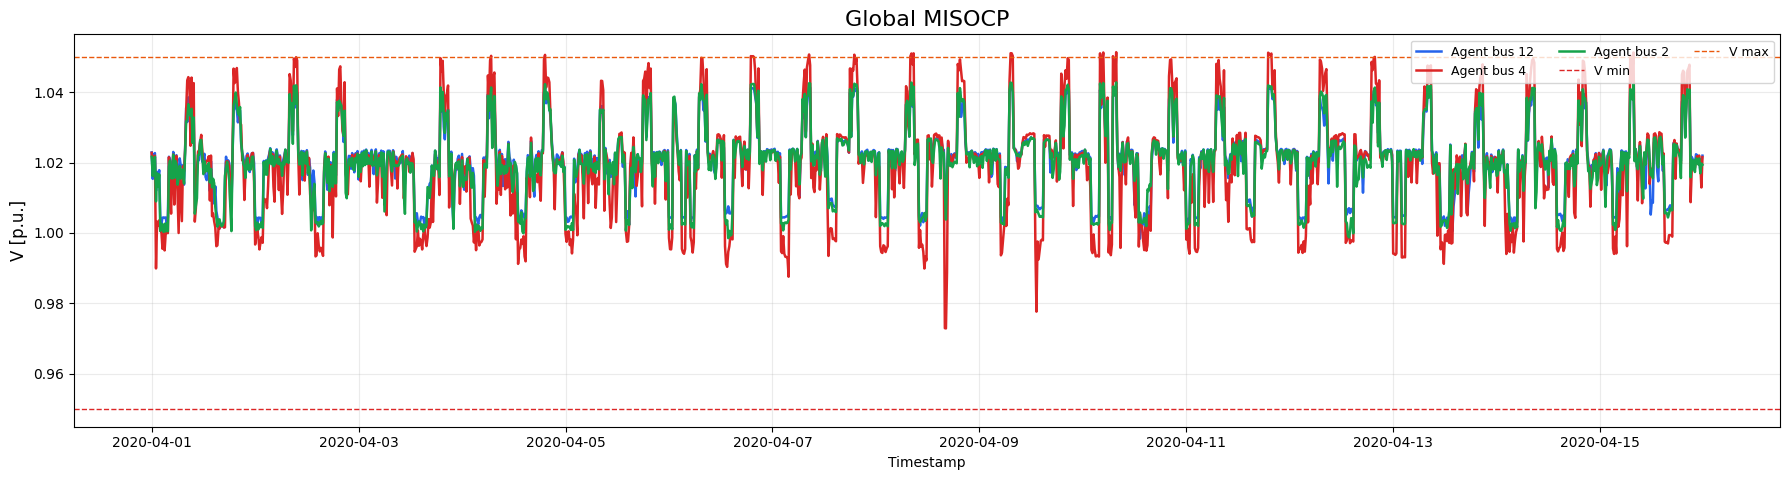

5. 净负荷

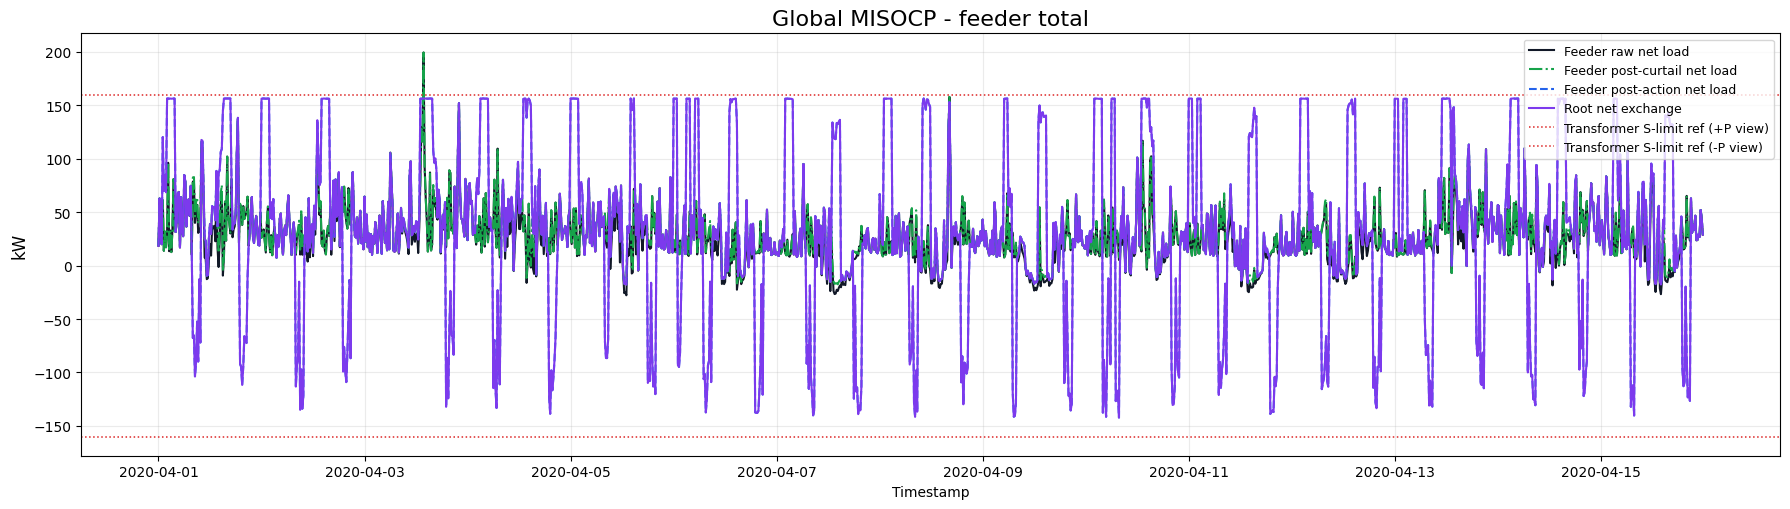

In [4]:
figures = plot_misocp_outputs(record, run_dir)
_plot_specs = [
    ("1. 电力电量平衡", "misocp_power_balance"),
    ("2. 电价", "misocp_price"),
    ("3. 总体储能充放功率与 SoC", "misocp_battery_soc"),
    ("4. 电压", "misocp_voltage"),
    ("5. 净负荷", "misocp_net_load"),
]
for title, name in _plot_specs:
    print(title)
    display(figures[name])
    plt.close(figures[name])
